<a href="https://colab.research.google.com/github/enzozavaleta/EXAMENPARCIAL/blob/main/Ejercicio2_CodigoParte3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- RESULTADOS NUMÉRICOS PARTE 3 ---
Primer cruce por cero (Intervalo [55.0, 57.5] kHz):
  • Bisección Lineal de la tabla: f = 55.56641 kHz
  • Refinado con Spline Cúbico:    f = 55.43507 kHz

Segundo cruce por cero (Intervalo [62.5, 65.0] kHz):
  • Bisección Lineal de la tabla: f = 64.13452 kHz
  • Refinado con Spline Cúbico:    f = 64.26647 kHz



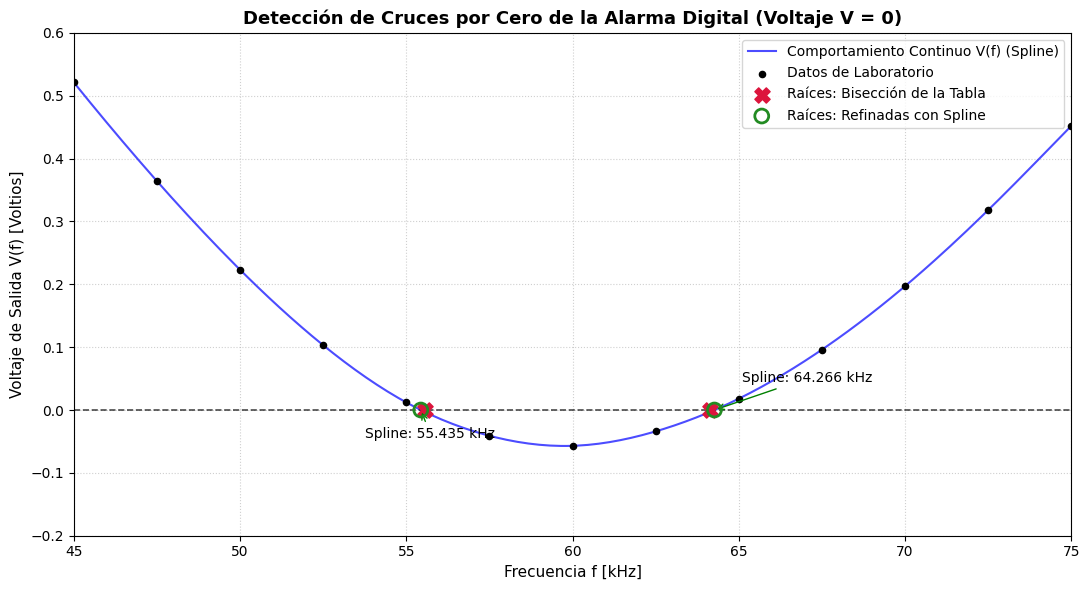

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d
from scipy.optimize import root_scalar

# 1. Definición de los datos del ensayo (proporcionados en el examen)
f = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0,
    52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5,
    95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])

V = np.array([
    0.842, 0.911, 0.986, 1.062, 1.143, 1.227, 1.314, 1.401, 1.482, 1.551, 1.216, 1.048, 0.866, 0.689, 0.521,
    0.364, 0.223, 0.103, 0.012, -0.041, -0.057, -0.034, 0.018, 0.096, 0.197, 0.318, 0.452, 0.579, 0.700,
    0.809, 0.611, 0.688, 0.756, 0.811, 0.856, 0.894, 0.926, 0.954, 0.980, 1.004
])

# 2. Algoritmo clásico del Método de la Bisección
def bisection_method(func, a, b, tol=1e-5, max_iter=100):
    if func(a) * func(b) >= 0:
        return None
    for _ in range(max_iter):
        c = (a + b) / 2
        if abs(func(c)) < tol or (b - a) / 2 < tol:
            return c
        if func(c) * func(a) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2

# Interpolación lineal local de la tabla para simular el comportamiento directo entre los datos discretos
f_linear = interp1d(f, V, kind='linear')

# Construcción del Spline Cúbico Natural para un modelado suave continuo
cs_V = CubicSpline(f, V, bc_type='natural')

# 3. Cálculo de raíces (Cruces por cero identificados en la tabla)
# Primer cruce: Intervalo [55.0, 57.5]
raiz1_bis = bisection_method(f_linear, 55.0, 57.5)
raiz1_spline = root_scalar(cs_V, bracket=[55.0, 57.5], method='brentq').root

# Segundo cruce: Intervalo [62.5, 65.0]
raiz2_bis = bisection_method(f_linear, 62.5, 65.0)
raiz2_spline = root_scalar(cs_V, bracket=[62.5, 65.0], method='brentq').root

# --- IMPRESIÓN DE RESULTADOS EN CONSOLA ---
print("--- RESULTADOS NUMÉRICOS PARTE 3 ---")
print(f"Primer cruce por cero (Intervalo [55.0, 57.5] kHz):")
print(f"  • Bisección Lineal de la tabla: f = {raiz1_bis:.5f} kHz")
print(f"  • Refinado con Spline Cúbico:    f = {raiz1_spline:.5f} kHz\n")

print(f"Segundo cruce por cero (Intervalo [62.5, 65.0] kHz):")
print(f"  • Bisección Lineal de la tabla: f = {raiz2_bis:.5f} kHz")
print(f"  • Refinado con Spline Cúbico:    f = {raiz2_spline:.5f} kHz\n")

# --- GENERACIÓN DE GRÁFICOS PARTE 3 ---
f_smooth = np.linspace(f.min(), f.max(), 600)

plt.figure(figsize=(11, 6))

# Dibujar la curva continua de voltaje y los puntos experimentales
plt.plot(f_smooth, cs_V(f_smooth), label='Comportamiento Continuo V(f) (Spline)', color='blue', alpha=0.7)
plt.scatter(f, V, color='black', s=20, label='Datos de Laboratorio', zorder=2)

# Línea horizontal de referencia en V = 0 para ver los cruces
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# Graficar y resaltar las raíces calculadas
plt.scatter([raiz1_bis, raiz2_bis], [0, 0], color='crimson', marker='X', s=120,
            label='Raíces: Bisección de la Tabla', zorder=3)
plt.scatter([raiz1_spline, raiz2_spline], [0, 0], color='forestgreen', marker='o', s=100, facecolors='none', linewidths=2,
            label='Raíces: Refinadas con Spline', zorder=4)

# Hacer un zoom visual en la ventana crítica de cruces por cero (f entre 45 y 75 kHz)
plt.xlim(45.0, 75.0)
plt.ylim(-0.2, 0.6)

# Detalles de formato técnico
plt.title("Detección de Cruces por Cero de la Alarma Digital (Voltaje V = 0)", fontsize=13, fontweight='bold')
plt.xlabel("Frecuencia f [kHz]", fontsize=11)
plt.ylabel("Voltaje de Salida V(f) [Voltios]", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

# Anotaciones de las raíces encontradas en el gráfico
plt.annotate(f"Spline: {raiz1_spline:.3f} kHz", (raiz1_spline, 0), textcoords="offset points", xytext=(-40,-20), arrowprops=dict(arrowstyle="->", color='green'))
plt.annotate(f"Spline: {raiz2_spline:.3f} kHz", (raiz2_spline, 0), textcoords="offset points", xytext=(20,20), arrowprops=dict(arrowstyle="->", color='green'))

plt.tight_layout()
plt.show()
